In [1]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np

data = pd.read_csv("combined_data.csv")
print('All emojis: ',np.unique(data['emoji_char']))

All emojis:  ['☀️' '☺️' '✅' '✔️' '✨' '❤️' '🍳' '🎉' '🐇' '🐣' '🐰' '👀' '👉' '👍' '👻' '💀' '💩'
 '🔥' '🖕' '😂' '😅' '😇' '😉' '😋' '😍' '😎' '😡' '😤' '😨' '😭' '🙏' '🤍' '🤔' '🤡' '🤣'
 '🥚' '🥰' '🥲' '🥳' '🥵' '🥹' '🫠' '🫡']


In [4]:
# similar emojis
# 🐇 rabbit 🐰 rabbit_face
# ❤️ red_heart 🤍 white_heart
# 😍 smiling_face_with_heart-eyes 🥰 smiling_face_with_hearts
# ✅ check_mark_button ✔️ check_mark
# 😂 face_with_tears_of_joy 🤣 rolling_on_the_floor_laughing
# 🎉 party_popper 🥳 partying_face

mask = {
    'rabbit_face': 'rabbit',
    'white_heart': 'red_heart',
    'smiling_face_with_hearts': 'smiling_face_with_heart-eyes',
    'check_mark': 'check_mark_button',
    'rolling_on_the_floor_laughing': 'face_with_tears_of_joy',
    'partying_face': 'party_popper'
}

# mask emoji by grouping with similar ones
data['emoji_group'] = data['emoji_label'].map(mask)
# fill unlabeled with the original emoji
data['emoji_group'] = data['emoji_group'].fillna(data['emoji_label'])

In [5]:
print(np.unique(data['emoji_group']))

# check 43-6 masked = 37
print(data['emoji_group'].nunique())

['backhand_index_pointing_right' 'check_mark_button' 'clown_face'
 'cooking' 'egg' 'enraged_face' 'eyes' 'face_holding_back_tears'
 'face_savoring_food' 'face_with_steam_from_nose' 'face_with_tears_of_joy'
 'fearful_face' 'fire' 'folded_hands' 'ghost' 'grinning_face_with_sweat'
 'hatching_chick' 'hot_face' 'loudly_crying_face' 'melting_face'
 'middle_finger' 'party_popper' 'pile_of_poo' 'rabbit' 'red_heart'
 'saluting_face' 'skull' 'smiling_face' 'smiling_face_with_halo'
 'smiling_face_with_heart-eyes' 'smiling_face_with_sunglasses'
 'smiling_face_with_tear' 'sparkles' 'sun' 'thinking_face' 'thumbs_up'
 'winking_face']
37


In [6]:
# all our emojis
emoji_names = [
    "backhand_index_pointing_right", "egg", "red_heart", "partying_face",
    "face_savoring_food", "thinking_face", "smiling_face_with_sunglasses",
    "hatching_chick", "hot_face", "white_heart", "party_popper", "skull",
    "rabbit", "rabbit_face", "smiling_face", "smiling_face_with_heart-eyes",
    "folded_hands", "fire", "melting_face", "middle_finger", "saluting_face",
    "check_mark_button", "ghost", "face_with_steam_from_nose", "sparkles",
    "face_holding_back_tears", "fearful_face", "sun", "eyes",
    "smiling_face_with_hearts", "smiling_face_with_tear",
    "rolling_on_the_floor_laughing", "check_mark", "pile_of_poo",
    "cooking", "enraged_face", "loudly_crying_face", "winking_face",
    "face_with_tears_of_joy", "grinning_face_with_sweat", "thumbs_up",
    "smiling_face_with_halo", "clown_face"
]

# map emoji label to the actual emoji
emoji_map = {}

for name in emoji_names:
    # turn into emoji
    em = emoji.emojize(f":{name}:")
    emoji_map[name] = em

# map the new masked emojis
data['emoji_group_char'] = data['emoji_group'].map(emoji_map)

# check! should be 37
print(np.unique(data['emoji_group_char']))
print(data['emoji_group_char'].nunique())

['☀️' '☺️' '✅' '✨' '❤️' '🍳' '🎉' '🐇' '🐣' '👀' '👉' '👍' '👻' '💀' '💩' '🔥' '🖕'
 '😂' '😅' '😇' '😉' '😋' '😍' '😎' '😡' '😤' '😨' '😭' '🙏' '🤔' '🤡' '🥚' '🥲' '🥵' '🥹'
 '🫠' '🫡']
37


In [7]:
!pip install transformers accelerate datasets torch scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-0.6.0-py3-none-any.whl size=49719 sha256=a4d27b921158130fefc2986cc54fc90db8a51b3e2c9bd300466453467c42cb5e
  Stored in directory: /root/.cache/pip/wheels/0d/bf/a2/536017b4a6232aef0fb92831af35facd6590c0af0f3983f63b
Successfully built emoji
  Attempting uninstall: emoji
    Found existing installation: emoji 2.15.0
    Uninstalling emoji-2.15.0:
      Successfully uninstalled emoji-2.15.0


In [8]:
import torch
import csv
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

X = data['text_without_emoji'].tolist()
# using the newly grouped emojis
y = data['emoji_group'].tolist()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
# make sure this is 37!!!! emojis now
print(f'Total number of unique emoji classes: {len(label_encoder.classes_)}')

X_train, X_test, y_train_enc, y_test_enc = train_test_split(
    X, y_encoded, test_size=0.2, random_state=12, stratify=y_encoded
)

train_df = pd.DataFrame({'text': X_train, 'label': y_train_enc})
test_df = pd.DataFrame({'text': X_test, 'label': y_test_enc})
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

tokenizer = AutoTokenizer.from_pretrained('vinai/bertweet-base', use_fast=True)

def preprocess_text(text):
    new_text = []
    for t in str(text).split(" "):
        t = '@user' if t.startswith('@') and len(t) > 1 else t
        t = 'http' if t.startswith('http') else t
        new_text.append(t)
    return " ".join(new_text)

def tokenize_function(examples):
    processed_texts = [preprocess_text(t) for t in examples['text']]
    return tokenizer(processed_texts, truncation=True, padding='max_length', max_length=64)

tokenized_train_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text']
)

tokenized_test_dataset = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text']
)

model = AutoModelForSequenceClassification.from_pretrained(
    'vinai/bertweet-base',
    num_labels=len(label_encoder.classes_),
    hidden_dropout_prob=0.2,
)

training_args = TrainingArguments(
    output_dir='./results/bertweet_replicate',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=16,
    fp16=True,
    learning_rate=1e-5, # slower e
    weight_decay=0.01,
    max_grad_norm=1.0,
    optim='adamw_torch',
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    report_to='none'
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    weighted_f1 = f1_score(labels, predictions, average='weighted', zero_division=0)
    accuracy = accuracy_score(labels, predictions)

    return {
        'accuracy': accuracy,
        'weighted_f1': weighted_f1,
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

Total number of unique emoji classes: 37


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/688056 [00:00<?, ? examples/s]

Map:   0%|          | 0/172015 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2683816040.py:89: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

In [9]:
trainer.train()

results = trainer.evaluate()
print(results)

Epoch,Training Loss,Validation Loss,Accuracy,Weighted F1
1,2.689600,2.647437,0.268331,0.241457


Epoch,Training Loss,Validation Loss,Accuracy,Weighted F1
1,2.689600,2.647437,0.268331,0.241457
2,2.612800,2.565747,0.289225,0.266897
3,2.560400,2.545302,0.295003,0.276529


{'eval_loss': 2.545301675796509, 'eval_accuracy': 0.2950033427317385, 'eval_weighted_f1': 0.276528831331279, 'eval_runtime': 162.1677, 'eval_samples_per_second': 1060.723, 'eval_steps_per_second': 66.296, 'epoch': 3.0}


In [10]:
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np

pred_output = trainer.predict(tokenized_test_dataset)
logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=-1)
classes = label_encoder.classes_

precisions, recalls, f1s, supports = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=range(len(classes))
)

df_metrics = pd.DataFrame({
    "emoji": classes,
    "precision": precisions,
    "recall": recalls,
    "f1": f1s,
    "support": supports
})

print(df_metrics)


                            emoji  precision    recall        f1  support
0   backhand_index_pointing_right   0.538219  0.595856  0.565573     4006
1               check_mark_button   0.524406  0.576053  0.549017     8001
2                      clown_face   0.277140  0.241250  0.257952     4000
3                         cooking   0.309197  0.541250  0.393565     4000
4                             egg   0.453032  0.360410  0.401448     4001
5                    enraged_face   0.294352  0.388250  0.334843     4000
6                            eyes   0.271311  0.156750  0.198701     4000
7         face_holding_back_tears   0.214073  0.233500  0.223365     4000
8              face_savoring_food   0.364001  0.340250  0.351725     4000
9       face_with_steam_from_nose   0.193075  0.092000  0.124619     4000
10         face_with_tears_of_joy   0.223714  0.353956  0.274153     8001
11                   fearful_face   0.220047  0.283750  0.247871     4000
12                           fire   0.

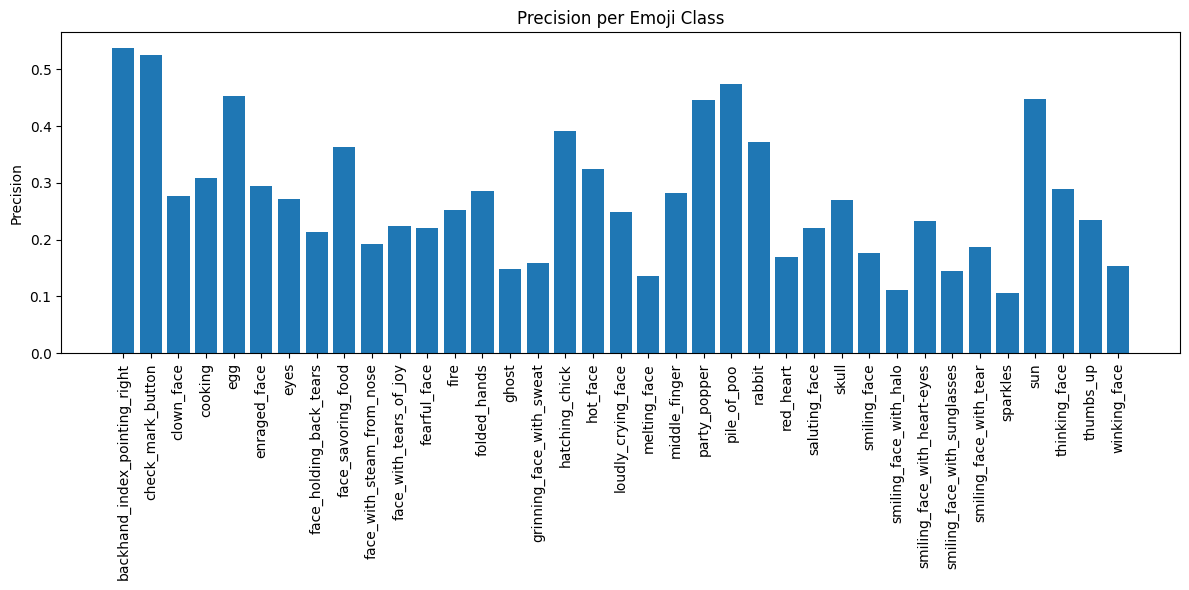

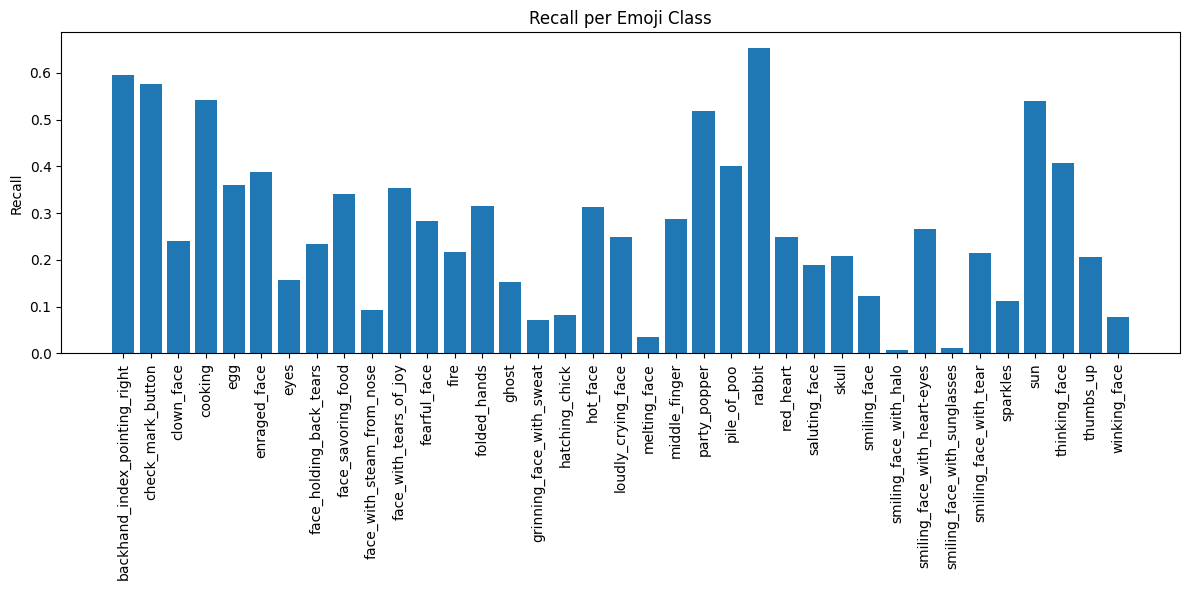

In [11]:
x = np.arange(len(classes))

plt.figure(figsize=(12, 6))
plt.bar(x, precisions)
plt.xticks(x, classes, rotation=90)
plt.ylabel("Precision")
plt.title("Precision per Emoji Class")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(x, recalls)
plt.xticks(x, classes, rotation=90)
plt.ylabel("Recall")
plt.title("Recall per Emoji Class")
plt.tight_layout()
plt.show()
